here i want to load the differentially expressed genes found in all the datasets of my meta analysis. 

- these are 6 tsv files containing the DE results with gene symbols.
- be careful that the gene symbol column may have different names in different files
- i want to find the common genes that are differentially expressed in all datasets
- additionally there are 3 groups: human, resistent cell lines and persistent cell lines. each group has 2 datasets.

firstly load the DE results for all the datasets.

In [2]:
# load necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [3]:
# import all the DE results from the upstream folder (all the files in that folder)
path_to_DE_results = "/Users/alvise/Documents/uni/semestre3/laboratory_bio_datamining/assessing_mutation_frequency_EGFR_NSCLC/top_common_genes"
# load the DE results  --- IGNORE ---
de_files = [f for f in os.listdir(path_to_DE_results) if f.endswith("_DE_results_with_symbols.tsv")]
de_dfs = {}
for file in de_files:
    df = pd.read_csv(os.path.join(path_to_DE_results, file), sep="\t")
    de_dfs[file] = df

# now de_dfs is a dictionary with filenames as keys and dataframes as values
#check the keys
de_dfs.keys()

dict_keys(['GSE278222_DE_results_with_symbols.tsv', 'GSE253742_DE_results_with_symbols.tsv', 'GSE274293_DE_results_with_symbols.tsv', 'GSE249721_DE_results_with_symbols.tsv', 'GSE283536_DE_results_with_symbols.tsv', 'GSE202859_DE_results_with_symbols.tsv'])

now for each datasets find the gene symbol column and rename it to "GeneSymbol" for consistency.
- dataset ...859 -> "gene_sym"
- dataset ...721 -> "symbol"
- dataset ...742 -> "gene_symbol"
- dataset ...293 -> "symbol"
- dataset ...222 -> "symbol"
-dataset ...536 -> "GENE_SYMBOL"


In [4]:
# Define all possible renaming rules in one dictionary
rename_map = {
    "gene_sym": "gene_symbol",
    "symbol": "gene_symbol",
    "GENE_SYMBOL": "gene_symbol",
    "padj": "adj.P.Val",
    "log2FoldChange": "logFC"
}

# Loop through datasets and apply the map
for key in de_dfs.keys():
    # This will look for any of the keys in the dictionary and rename them.
    # If a column isn't found (e.g., 'GENE_SYMBOL' isn't there), it just ignores it safely.
    de_dfs[key] = de_dfs[key].rename(columns=rename_map)

# Check the columns of each dataframe to confirm
for key in de_dfs.keys():
    print(f"{key} columns: {de_dfs[key].columns.tolist()}")





GSE278222_DE_results_with_symbols.tsv columns: ['gene_id', 'baseMean', 'logFC', 'lfcSE', 'pvalue', 'adj.P.Val', 'gene_symbol']
GSE253742_DE_results_with_symbols.tsv columns: ['gene_symbol', 'logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B']
GSE274293_DE_results_with_symbols.tsv columns: ['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'gene_symbol']
GSE249721_DE_results_with_symbols.tsv columns: ['index', 'logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'gene_symbol', 'symbol_2']
GSE283536_DE_results_with_symbols.tsv columns: ['gene_id', 'logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'gene_symbol']
GSE202859_DE_results_with_symbols.tsv columns: ['gene_id', 'gene_symbol', 'logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B']


now create a new dataframe by merigin all the dataframes on the gene symbol column. use inner join to keep only common genes.
for this new dataframe , keep the gene symbol column and the log fold change and the adjusted p-value columns from each dataset.

In [5]:
# 1. Initialize a set with the genes from the first dataset
first_key = list(de_dfs.keys())[0]
# We drop NA values immediately to prevent "float" errors
common_genes = set(de_dfs[first_key]["gene_symbol"].dropna())

print(f"Starting with {len(common_genes)} genes from {first_key}...")

# 2. Loop through the rest and find the intersection
for key in de_dfs.keys():
    # Drop NA values here too
    current_genes = set(de_dfs[key]["gene_symbol"].dropna())
    
    # Update our common set
    common_genes = common_genes.intersection(current_genes)
    
    print(f"After intersecting with {key}, {len(common_genes)} genes remain.")

# 3. Convert to sorted list, filtering out any accidental non-strings
# This list comprehension ensures ONLY strings are passed to sorted()
clean_genes = [g for g in common_genes if isinstance(g, str)]

common_genes_df = pd.DataFrame(sorted(clean_genes), columns=["gene_symbol"])

# 4. Check the result
print(f"\nFinal Result: Found {len(common_genes_df)} genes present in ALL 6 datasets.")
print(common_genes_df.head())

Starting with 18759 genes from GSE278222_DE_results_with_symbols.tsv...
After intersecting with GSE278222_DE_results_with_symbols.tsv, 18759 genes remain.
After intersecting with GSE253742_DE_results_with_symbols.tsv, 12380 genes remain.
After intersecting with GSE274293_DE_results_with_symbols.tsv, 12375 genes remain.
After intersecting with GSE249721_DE_results_with_symbols.tsv, 5428 genes remain.
After intersecting with GSE283536_DE_results_with_symbols.tsv, 4942 genes remain.
After intersecting with GSE202859_DE_results_with_symbols.tsv, 4638 genes remain.

Final Result: Found 4638 genes present in ALL 6 datasets.
  gene_symbol
0        AAAS
1       AAMDC
2        AAMP
3        AASS
4       ABCA1


now that i have a dataframe with the genes symbols found in all datasets. i want to get the adjusted p-values for each group and sum them in a new column called "Sum_Adj_Pval".

In [6]:
# 1. Create a clean copy of your common genes dataframe to start
final_df = common_genes_df.copy()

# Keep track of the column names we create
pval_columns = []

for key in de_dfs.keys():
    # A. Extract only gene_symbol and adj.P.Val
    # Ensure we work with a copy to avoid settingwithcopy warnings
    current_subset = de_dfs[key][["gene_symbol", "adj.P.Val"]].copy()
    
    # B. Handle Duplicates: Sort by P-value and keep the lowest (most significant)
    # This prevents the "exploding rows" issue if a gene appears twice in one file
    current_subset = current_subset.sort_values("adj.P.Val", ascending=True)
    current_subset = current_subset.drop_duplicates(subset="gene_symbol", keep="first")
    
    # C. Rename the p-value column to match the dataset (e.g., "GSE123_adj_PVal")
    # We strip the filename extension for a cleaner column name
    clean_key = key.split("_")[0] 
    new_col_name = f"{clean_key}_adj_PVal"
    current_subset = current_subset.rename(columns={"adj.P.Val": new_col_name})
    
    # Add to our list of columns to sum later
    pval_columns.append(new_col_name)
    
    # D. Merge into the final dataframe
    # We use 'left' merge to keep only the genes in our 'common_genes_df' list
    final_df = pd.merge(final_df, current_subset, on="gene_symbol", how="left")

# 2. Calculate the Sum
# axis=1 means "sum across the row"
final_df["Fisher_Score"] = -2 * np.log(final_df[pval_columns] + 1e-200).sum(axis=1)
# alert: if any p-value is zero, log(0) is undefined, resulting in -inf. To avoid this, you might want to add a small constant to p-values before log transformation.
final_df["simple_sum"] = final_df[pval_columns].sum(axis=1)

# 3. Sort by the sum (optional, but usually you want the smallest sums first)
#final_df = final_df.sort_values("Fisher_Score", ascending=False)
# sort by simple sum column ascending
final_df = final_df.sort_values("simple_sum", ascending=True)

# 3.5 remove the individual p-value columns to keep it clean
#final_df = final_df.drop(columns=pval_columns)

# 3.6 include the logFC columns of each dataset
for key in de_dfs.keys():
    # A. Extract only gene_symbol and logFC
    current_subset = de_dfs[key][["gene_symbol", "logFC"]].copy()
    
    # B. Handle Duplicates: Sort by absolute logFC and keep the largest
    current_subset = current_subset.reindex(current_subset['logFC'].abs().sort_values(ascending=False).index)
    current_subset = current_subset.drop_duplicates(subset="gene_symbol", keep="first")
    
    # C. Rename the logFC column to match the dataset (e.g., "GSE123_logFC")
    clean_key = key.split("_")[0] 
    new_col_name = f"{clean_key}_logFC"
    current_subset = current_subset.rename(columns={"logFC": new_col_name})
    
    # D. Merge into the final dataframe
    final_df = pd.merge(final_df, current_subset, on="gene_symbol", how="left")

# 4. View the first 20 results
print(final_df.head(3))

  gene_symbol  GSE278222_adj_PVal  GSE253742_adj_PVal  GSE274293_adj_PVal  \
0      S100A2        2.301850e-05            0.095471            0.477080   
1       SFTPB        5.196546e-07            0.157464            0.027093   
2        IRS1        5.550362e-04            0.060229            1.000000   

   GSE249721_adj_PVal  GSE283536_adj_PVal  GSE202859_adj_PVal  Fisher_Score  \
0            0.001072            0.105036            0.000014     68.105638   
1            0.001239            0.710704            0.007611     63.680802   
2            0.002561            0.034511            0.006346     49.399606   

   simple_sum  GSE278222_logFC  GSE253742_logFC  GSE274293_logFC  \
0    0.678696         0.382586         2.066494        -3.186599   
1    0.904111        -7.616521        -2.527321        -4.228786   
2    1.104203        -0.259731         1.694669        -0.071397   

   GSE249721_logFC  GSE283536_logFC  GSE202859_logFC  
0        -1.746217        -0.238089        -3.

#### fhishers method or simple sum?
the fisher metod returned some nor linear results. i prefer to use the simple sum of adjusted p-values across datasets.

print the distribution of the summed adjusted p-values.

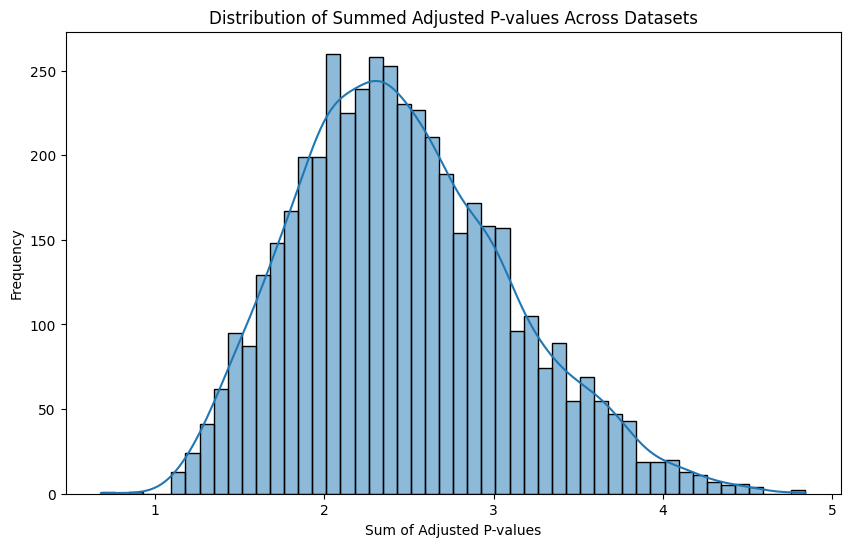

In [7]:
# graph of the distribution of the summed adjusted p-values
plt.figure(figsize=(10,6))
sns.histplot(final_df["simple_sum"], bins=50, kde=True)
plt.title("Distribution of Summed Adjusted P-values Across Datasets")
plt.xlabel("Sum of Adjusted P-values")
plt.ylabel("Frequency")
plt.show()



## create a meta heatmap 


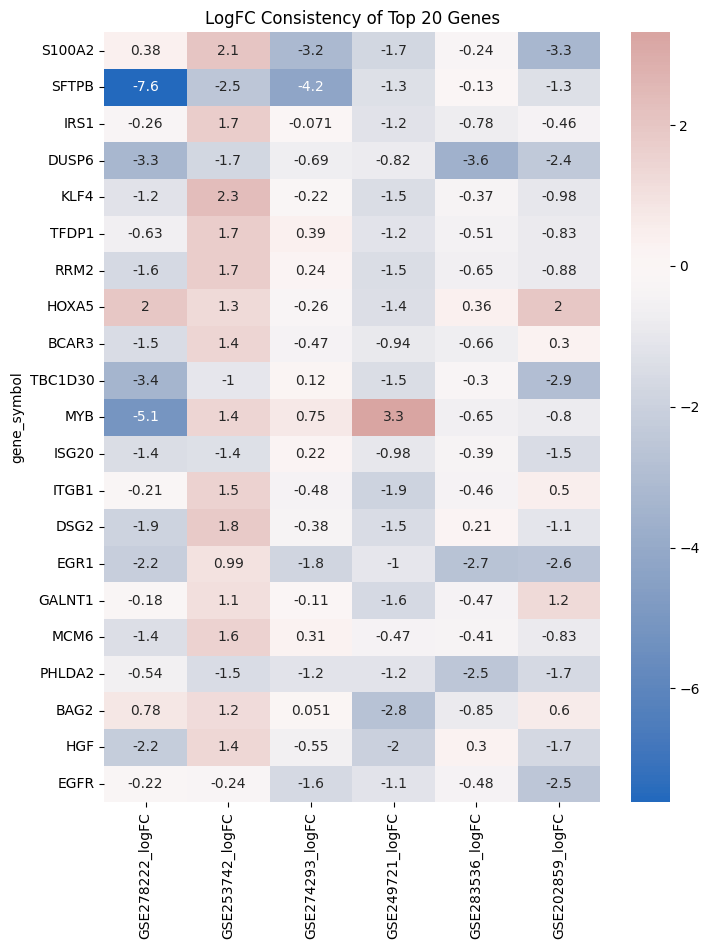

In [8]:
import seaborn as sns

# 1. Select Top N genes
top_n = 20
top_genes_df = final_df.sort_values("simple_sum", ascending=True).head(top_n)
# 1.1 add EGFR to the top genes if not already present
egfr_symbol = "EGFR"
if egfr_symbol not in top_genes_df["gene_symbol"].values:
    egfr_row = final_df[final_df["gene_symbol"] == egfr_symbol]
    top_genes_df = pd.concat([top_genes_df, egfr_row], ignore_index=True)

# 2. Extract only the LogFC columns
# (Assuming you kept columns like 'GSE123_logFC' in your merge step)
logfc_cols = [c for c in final_df.columns if "logFC" in c]
heatmap_data = top_genes_df.set_index("gene_symbol")[logfc_cols]

# 3. Plot
plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, cmap="vlag", center=0, annot=True)
plt.title(f"LogFC Consistency of Top {top_n} Genes")
plt.show()

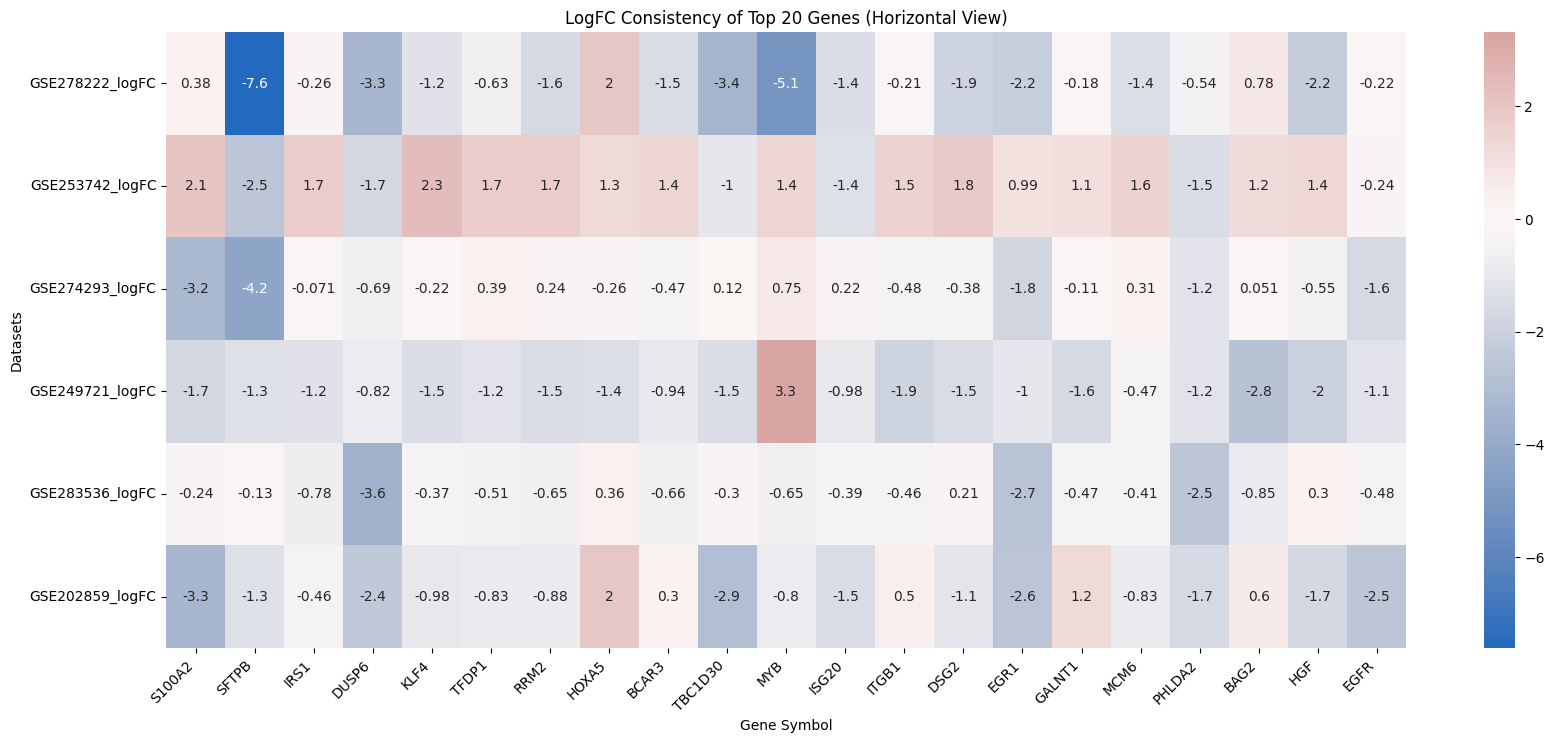

In [9]:
# create an alternative HORIZONTAL heatmap for better visualization, with oblique labels
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data.T, cmap="vlag", center=0, annot=True)
plt.title(f"LogFC Consistency of Top {top_n} Genes (Horizontal View)")
plt.xlabel("Gene Symbol")
plt.xticks(rotation=45, ha='right')  # Oblique labels for better readability
plt.ylabel("Datasets")
plt.show()

## create a meta volcano plot
Meta-Volcano plot is

- X-axis: Average LogFC (Mean of the 6 logFCs).
- Y-axis: Fisher's Combined Score (or -log10 of it).

This allows you to spot "globally significant" genes. You can color-code the points to highlight your Top N list.

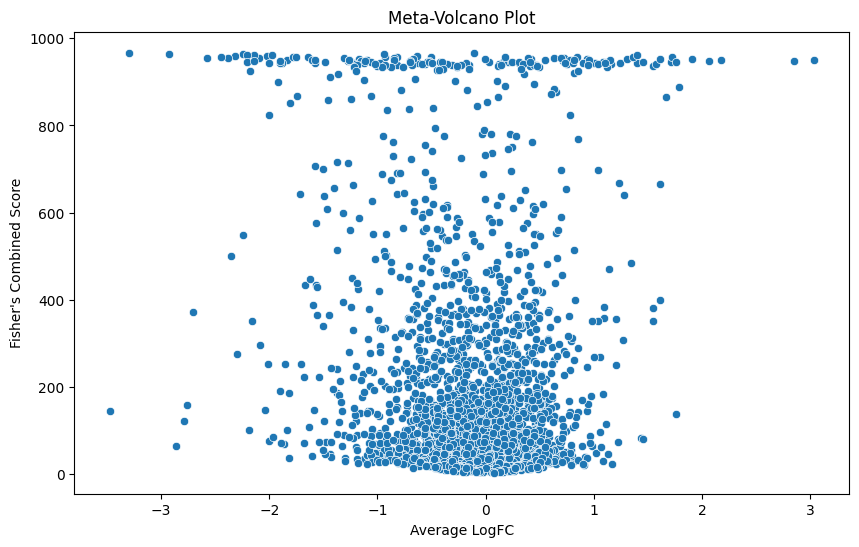

In [10]:
# final_df dataframe contains the logFC columns for each dataset, the adj_PVal columns (for each dataset), the Fisher_Score column, and the simple_sum column.
# now i need to create a meta-volcano plot
# to do that i need to create a new column with the average logFC across datasets. 
# then plot the average logFC on the x-axis and the Fisher_Score on the y-axis.
final_df["avg_logFC"] = final_df[[c for c in final_df.columns if "logFC" in c]].mean(axis=1)
# create the meta-volcano plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x="avg_logFC", y=(final_df["Fisher_Score"]))
plt.title("Meta-Volcano Plot")
plt.xlabel("Average LogFC")
plt.ylabel("Fisher's Combined Score")
plt.show()

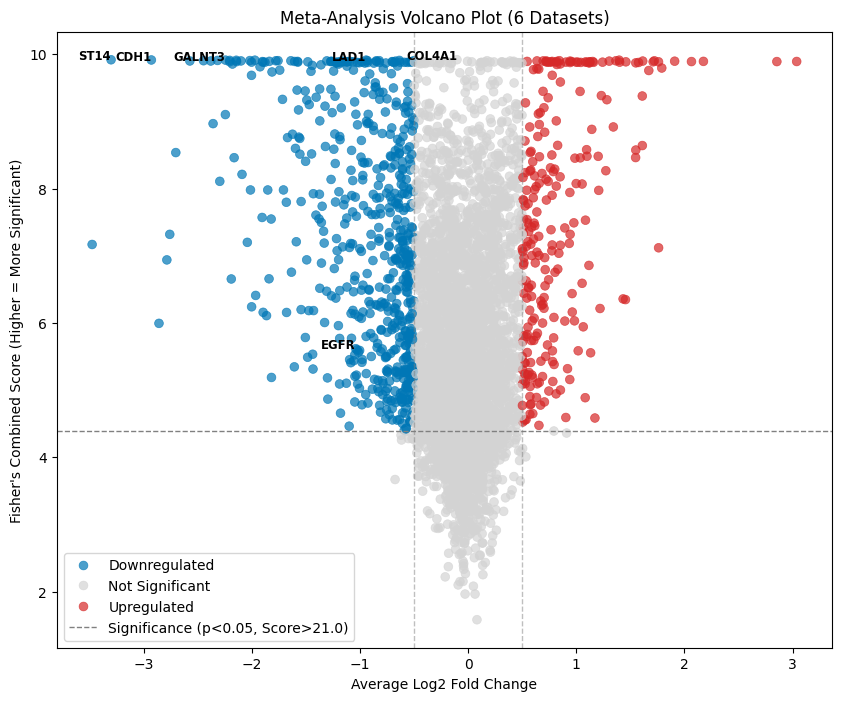

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# 1. Define Thresholds
n_studies = 6  # You have 6 datasets
degrees_of_freedom = 2 * n_studies
# Calculate critical Fisher score for p < 0.05 (Approx 21.03)
fisher_threshold = chi2.ppf(0.95, degrees_of_freedom) 
logfc_threshold = 0.5  # Adjust this if you want stricter fold-change filters

# 2. Categorize Genes for Coloring
def get_color_category(row):
    if row["Fisher_Score"] > fisher_threshold:
        if row["avg_logFC"] > logfc_threshold:
            return "Upregulated"
        elif row["avg_logFC"] < -logfc_threshold:
            return "Downregulated"
    return "Not Significant"

final_df["Significance"] = final_df.apply(get_color_category, axis=1)

# 3. Create the Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=final_df, 
    x="avg_logFC", 
    y=np.log2(final_df["Fisher_Score"]+1e-100),  # use -log10 for better visualization
    hue="Significance",
    palette={"Upregulated": "#D62828", "Downregulated": "#0077B6", "Not Significant": "lightgrey"},
    alpha=0.7,
    edgecolor=None,
    s=40 # Dot size
)

# 4. Add Reference Lines
plt.axhline(np.log2(fisher_threshold), linestyle="--", color="grey", linewidth=1, label=f"Significance (p<0.05, Score>{fisher_threshold:.1f})")
plt.axvline(logfc_threshold, linestyle="--", color="grey", linewidth=1, alpha=0.5)
plt.axvline(-logfc_threshold, linestyle="--", color="grey", linewidth=1, alpha=0.5)

# 5. Annotate Top 10 Genes
# Sort by Fisher Score to find the most significant ones
top_genes = final_df.sort_values("Fisher_Score", ascending=False).head(5)
# add EGFR if not already in top genes
if "EGFR" not in top_genes["gene_symbol"].values:
    egfr_row = final_df[final_df["gene_symbol"] == "EGFR"]
    top_genes = pd.concat([top_genes, egfr_row], ignore_index=True)

for _, row in top_genes.iterrows():
    plt.text(
        row["avg_logFC"], 
        np.log2(row["Fisher_Score"]+1e-100), 
        row["gene_symbol"], # Make sure 'gene_symbol' is a column name, not index
        horizontalalignment='right' if row["avg_logFC"] < 0 else 'left',
        size='small',
        color='black',
        weight='bold'
    )

# 6. Final Polish
plt.title(f"Meta-Analysis Volcano Plot ({n_studies} Datasets)")
plt.xlabel("Average Log2 Fold Change")
plt.ylabel("Fisher's Combined Score (Higher = More Significant)")
plt.legend(loc='lower left')
plt.grid(False)
plt.show()

## forest plot for EGFR across datasets
For your absolute "star" genes (like EGFR or your #1 discovery), use a Forest Plot.

    Y-axis: The 6 study names.

    X-axis: Log Fold Change.

    Point: The LogFC for that study.

    Error Bars: The Confidence Interval (optional, or just use standard error).

    Summary Diamond: The "Combined Effect Size" (average LogFC).

Why this is best: It shows heterogeneity. It answers: "Is the downregulation driven by one massive dataset, or is the effect size consistent across all patients and cell lines?"

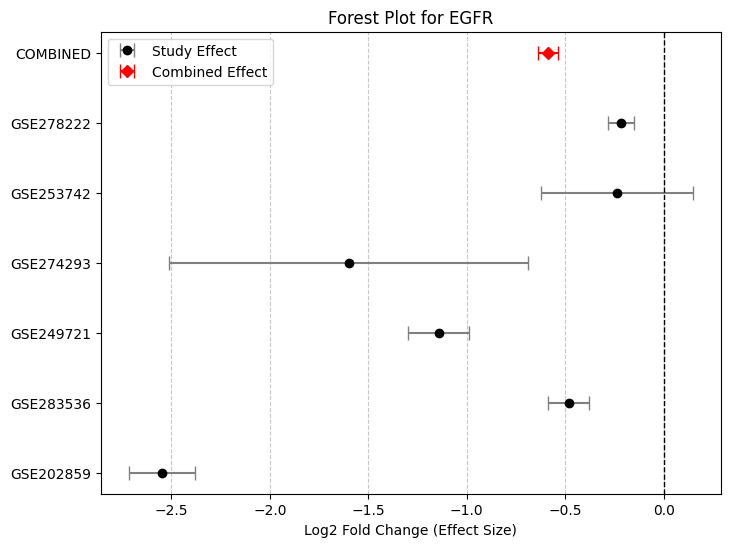

In [12]:
# Function to create a forest plot for a given gene
import matplotlib.pyplot as plt
import numpy as np

def plot_forest(gene_name, de_dfs):
    studies = []
    logfcs = []
    ses = []
    
    # Loop through all datasets to find data for this gene
    for key in de_dfs.keys():
        # Get the specific row for this gene
        df = de_dfs[key]
        gene_data = df[df["gene_symbol"] == gene_name]
        
        if gene_data.empty:
            continue
            
        # Extract LogFC
        # Handle different column names for LogFC
        if "logFC" in gene_data.columns:
            lfc = gene_data["logFC"].values[0]
        elif "log2FoldChange" in gene_data.columns: # DESeq2
            lfc = gene_data["log2FoldChange"].values[0]
        else:
            continue # Skip if we can't find LogFC
            
        # Extract or Calculate Standard Error (SE)
        if "lfcSE" in gene_data.columns:
            # Case 1: DESeq2 (GSE278222) has explicit SE
            se = gene_data["lfcSE"].values[0]
        elif "t" in gene_data.columns:
            # Case 2: Limma (others) - Calculate SE from t-stat
            t_stat = gene_data["t"].values[0]
            se = lfc / t_stat
        else:
            # Fallback if neither is present (unlikely)
            continue
            
        studies.append(key.split("_")[0]) # Clean name
        logfcs.append(lfc)
        ses.append(abs(se)) # Ensure SE is positive

    # --- Create the Forest Plot ---
    plt.figure(figsize=(8, 6))
    
    # 1. Plot the individual studies
    y_pos = np.arange(len(studies))
    plt.errorbar(logfcs, y_pos, xerr=ses, fmt='o', color='black', 
                 ecolor='grey', capsize=5, label="Study Effect")
    
    # 2. Add the "Combined" effect (Weighted Average)
    # Inverse Variance Weighting
    weights = 1 / (np.array(ses)**2)
    combined_lfc = np.sum(weights * logfcs) / np.sum(weights)
    combined_se = np.sqrt(1 / np.sum(weights))
    
    # Plot the diamond (Combined Effect) at the bottom
    plt.errorbar(combined_lfc, -1, xerr=combined_se, fmt='D', color='red', 
                 capsize=5, label="Combined Effect")
    
    # 3. Formatting
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.yticks(list(y_pos) + [-1], studies + ["COMBINED"])
    plt.xlabel("Log2 Fold Change (Effect Size)")
    plt.title(f"Forest Plot for {gene_name}")
    plt.gca().invert_yaxis() # Put the first study at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# --- Usage ---
# Plot for your top gene
plot_forest("EGFR", de_dfs)

## Functional Enrichment Analysis or GSEA
use the pakage gseapy to perform GSEA analysis on the top common genes found in all datasets.

---

run GSEA (Gene Set Enrichment Analysis) or ORA (Over-Representation Analysis) on your common genes.

Do the common genes belong to "EGFR Signaling"? "Cell Cycle"? "Apoptosis"?

This moves your conclusion from "Here is a list of genes" to "Osimertinib consistently shuts down the Cell Cycle machinery across all models."

Tool: In Python, use the gseapy library.

Ranking list ready. Top genes:
     gene_symbol  ranking_metric
3678        NNMT      962.557254
1247      RASSF2      957.354019
2250      SQSTM1      957.261932
620        ABCB1      956.371905
2099       CLDN2      956.168303
Running GSEA...
Top Enriched Pathways:
                                Term       NES FDR q-val
0                        E2F Targets -1.772283  0.005396
2                  KRAS Signaling Up -1.624338  0.021136
5             Estrogen Response Late -1.555232    0.0371
4                    G2-M Checkpoint -1.565308   0.04437
3                       Angiogenesis  1.616017  0.049534
8              Fatty Acid Metabolism  1.506439  0.055622
6  Epithelial Mesenchymal Transition  1.548857  0.060476
1         Wnt-beta Catenin Signaling  1.651876  0.068035
7                    Notch Signaling  1.506871  0.069229
9                   mTORC1 Signaling -1.457442  0.104509


<Figure size 1000x1500 with 0 Axes>

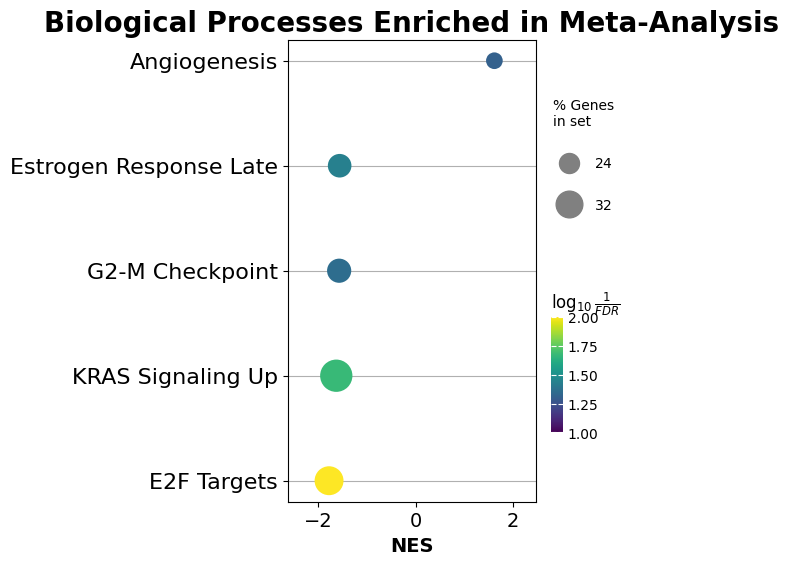

In [13]:
import gseapy as gp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Create the Ranking Metric ---
# We combine direction (sign of logFC) with significance (Fisher Score)
# This pushes the most consistently changed genes to the top and bottom of the list.
final_df["ranking_metric"] = np.sign(final_df["avg_logFC"]) * final_df["Fisher_Score"]

# HANDLE INFINITE VALUES: 
# If you had p=0, Fisher score is inf. We need to replace these with the max finite number
# so GSEA doesn't crash.
max_val = final_df.loc[final_df["ranking_metric"] != np.inf, "ranking_metric"].max()
min_val = final_df.loc[final_df["ranking_metric"] != -np.inf, "ranking_metric"].min()
final_df["ranking_metric"] = final_df["ranking_metric"].replace(np.inf, max_val + 1)
final_df["ranking_metric"] = final_df["ranking_metric"].replace(-np.inf, min_val - 1)

# Prepare the dataframe for GSEA (Gene Symbol + Metric)
rnk = final_df[["gene_symbol", "ranking_metric"]].sort_values("ranking_metric", ascending=False)

# Drop any NaNs just in case
rnk = rnk.dropna()

print("Ranking list ready. Top genes:")
print(rnk.head())

# --- 2. Run GSEA (Preranked) ---
# We use 'prerank' because we have a custom sorted list.
# 'gene_sets' options: 'KEGG_2021_Human', 'GO_Biological_Process_2021', 'Reactome_2022', 'MSigDB_Hallmark_2020'

print("Running GSEA...")
pre_res = gp.prerank(rnk=rnk, 
                     gene_sets='MSigDB_Hallmark_2020', # Try 'KEGG_2021_Human' too
                     threads=4,
                     min_size=10, # Minimum genes in pathway to consider
                     max_size=1000,
                     permutation_num=1000, # 1000 is standard for publication
                     seed=6,
                     outdir=None) # Don't save to disk yet

# --- 3. View Results ---
# The results are stored in pre_res.res2d
results_df = pre_res.res2d.sort_values("FDR q-val")

print("Top Enriched Pathways:")
print(results_df[["Term", "NES", "FDR q-val"]].head(10))

# --- 4. Visualize (Dot Plot) ---
from gseapy import dotplot

# Plot top 20 pathways
plt.figure(figsize=(10,15))
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title="Biological Processes Enriched in Meta-Analysis",
             cmap=plt.cm.viridis,
             size=10, # Adjust dot size
             top_term=20)
plt.show()

#### selected genes for a heatmap

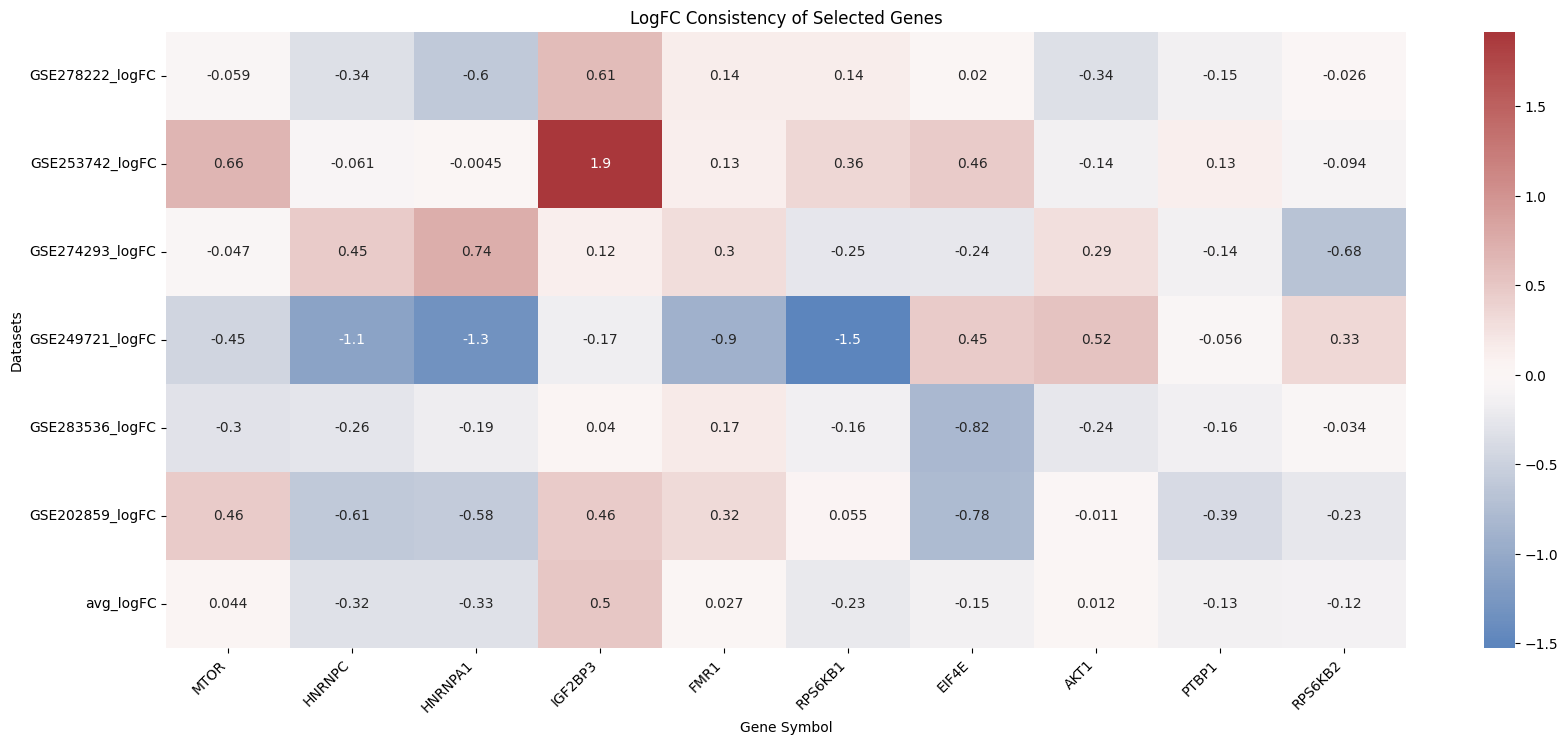

In [14]:
gene_list = [
    "EIF4E", "EIF4A", "EIF4G", "LARP1", "4EBP1", "mTORC1", "MTOR", "RPS6KB1", "RPS6KB2", "PTBP1", "AKT1", "IGF2BP1", "IGF2BP3", "HNRNPA1", "HNRNPC", "FMR1"
]

# create a dataframe for these genes from final_df
selected_genes_df = final_df[final_df["gene_symbol"].isin(gene_list)]
#print(selected_genes_df)

## ----- now create a heatmap like before but only for these genes -----
# extract only the logFC columns
logfc_cols = [c for c in final_df.columns if "logFC" in c]
heatmap_data = selected_genes_df.set_index("gene_symbol")[logfc_cols]   
# create an alternative HORIZONTAL heatmap for better visualization, with oblique labels
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data.T, cmap="vlag", center=0, annot=True)
plt.title(f"LogFC Consistency of Selected Genes")
plt.xlabel("Gene Symbol")
plt.xticks(rotation=45, ha='right')  # Oblique labels for better readability
plt.ylabel("Datasets")
plt.show()

## protein protein interaction network


In [15]:
out_path = "/Users/alvise/Documents/uni/semestre3/laboratory_bio_datamining/assessing_mutation_frequency_EGFR_NSCLC/top_common_genes/top_genes_string"
# --- 1. Extract Top 1000 by "Simple Sum" (Lower is better) ---
# We sort ascending because a smaller sum of p-values means more significant
top_sum = final_df.sort_values("simple_sum", ascending=True).head(1000)
list_sum = top_sum["gene_symbol"].tolist()

# Save to file (Simple Sum)
with open(f"{out_path}/top_1000_simple_sum.txt", "w") as f:
    for gene in list_sum:
        f.write(f"{gene}\n")

# --- 2. Extract Top 1000 by "Fisher's Score" (Higher is better) ---
# We sort descending because a higher Chi-square score means more significant
top_fisher = final_df.sort_values("Fisher_Score", ascending=False).head(1000)
list_fisher = top_fisher["gene_symbol"].tolist()

# Save to file (Fisher)
with open(f"{out_path}/top_1000_fisher_score.txt", "w") as f:
    for gene in list_fisher:
        f.write(f"{gene}\n")

# --- 3. Compare the overlap (Optional but interesting) ---
# Find genes present in BOTH lists
common_top_genes = set(list_sum).intersection(set(list_fisher))

print(f"Files saved successfully:")
print("1. top_1000_simple_sum.txt")
print("2. top_1000_fisher_score.txt")
print(f"\nOverlap: {len(common_top_genes)} genes are in the top 1000 of BOTH methods.")

Files saved successfully:
1. top_1000_simple_sum.txt
2. top_1000_fisher_score.txt

Overlap: 334 genes are in the top 1000 of BOTH methods.


#### conduct PPI analysis with STRING database
extract the hub genes from the 1000 top genes.
- both for the simple sum and for the fisher score.

In [16]:
import requests
import pandas as pd
import io

# 1. Use your Top 1000 list (from the previous step)
# Assuming you have the list in 'list_fisher' variable
# If loading from file:
# with open("top_1000_fisher_score.txt") as f:
#     my_genes = [line.strip() for line in f]
my_genes = list_sum  # Use the variable from your notebook

print(f"Analyzing network for {len(my_genes)} genes...")

# 2. STRING API Parameters
string_api_url = "https://string-db.org/api"
output_format = "tsv"
method = "network"

params = {
    "identifiers": "%0d".join(my_genes), # Join with newlines
    "species": 9606,       # Homo sapiens
    "caller_identity": "Meta_Analysis_1000",
    "required_score": 400  # Medium confidence is better for large networks to find more links
}

# 3. Call the API (This might take 10-20 seconds for 1000 genes)
print("Contacting STRING database...")
request_url = "/".join([string_api_url, output_format, method])
response = requests.post(request_url, data=params)

# 4. Convert to DataFrame
try:
    network_df = pd.read_csv(io.StringIO(response.content.decode('utf-8')), sep="\t")
    print(f"Success! Found {len(network_df)} interactions between your 1000 genes.")
    
    # 5. Calculate Hubs (Degree Centrality)
    # We count how many times each gene appears in the interaction list
    all_nodes = pd.concat([network_df["preferredName_A"], network_df["preferredName_B"]])
    hub_ranking = all_nodes.value_counts().reset_index()
    hub_ranking.columns = ["Gene", "Connections"]

    # 6. Display the True Master Regulators
    print("\n--- TOP 10 MASTER REGULATORS (Hubs) ---")
    print(hub_ranking.head(10))
    
    # Optional: Save to CSV for Cytoscape
    network_df.to_csv("string_interactions_1000.tsv", sep="\t", index=False)
    print("\nSaved full interaction network to 'string_interactions_1000.tsv'")

except Exception as e:
    print("Error parsing STRING response. You might have sent too many genes or the server timed out.")
    print(e)

Analyzing network for 1000 genes...
Contacting STRING database...
Success! Found 9283 interactions between your 1000 genes.

--- TOP 10 MASTER REGULATORS (Hubs) ---
       Gene  Connections
0       MYC          239
1      EGFR          199
2  HSP90AA1          153
3     BRCA1          139
4       UBC          132
5      CDK1          131
6     HSPA4          125
7      CDH1          115
8      CD44          104
9       ATM          101

Saved full interaction network to 'string_interactions_1000.tsv'


#### nice graph with PPI network


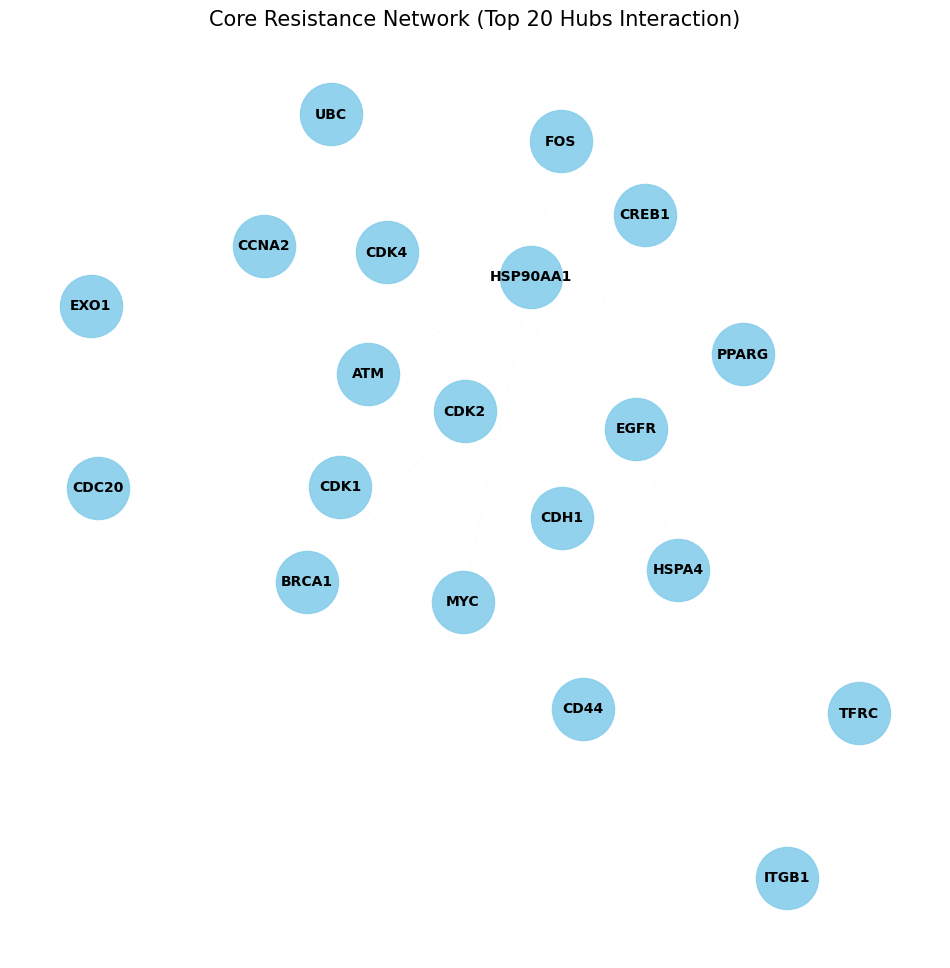

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define your Top Hubs (e.g., Top 20 from your previous analysis)
# Replace this with: top_hubs = hub_ranking["Gene"].head(20).tolist()
top_hubs = hub_ranking["Gene"].head(20).tolist()

# 2. Filter the network dataframe
# Keep only interactions where BOTH genes are in the Top 20 (Core Network)
# OR where at least ONE gene is in the Top 20 (Neighborhood)
# Let's do "Core Network" for the cleanest graph:
core_network = network_df[
    (network_df["preferredName_A"].isin(top_hubs)) & 
    (network_df["preferredName_B"].isin(top_hubs))
]

# 3. Create Graph Object
G = nx.from_pandas_edgelist(core_network, "preferredName_A", "preferredName_B", ["score"])

# 4. Plot
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.3, seed=42) # k regulates the distance between nodes

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="skyblue", alpha=0.9)

# Draw Edges (Width based on confidence score)
weights = [d['score']/100 for u,v,d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=weights, edge_color="grey", alpha=0.5)

# Draw Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight="bold")

plt.title("Core Resistance Network (Top 20 Hubs Interaction)", fontsize=15)
plt.axis("off")
plt.show()